In [1]:
import pandas as pd
df = pd.read_csv("analysis_dataset.csv")
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
# Only these text columns should be merged
text_cols = [
    'inspiration', 
    'what_it_does', 
    'how_we_built_it', 
    'challenges', 
    'accomplishments', 
    'what_we_learned',
    'what_is_next',
    'tech_stack'
]

# Combine selected columns into one text column
df['all_text'] = df[text_cols].astype(str).apply(lambda x: ' '.join(x), axis=1)

# Clean up text (remove 'nan', brackets, double spaces)
df['all_text'] = (
    df['all_text']
    .str.replace(r"\bnan\b", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df_ml = df[['is_winner', 'github_summary', 'all_text']]
# Drop rows with missing values (optional)
df_ml = df_ml.dropna(subset=['github_summary', 'all_text'])
df_ml['text'] = df_ml['all_text']
df_ml['label'] = df_ml['is_winner'].astype(int)
# Sample 1000 True and 1000 False examples randomly
df_true = df_ml[df_ml['is_winner'] == True].sample(n=1000, random_state=42)
df_false = df_ml[df_ml['is_winner'] == False].sample(n=1000, random_state=42)
df_balanced = pd.concat([df_true, df_false]).sample(frac=1, random_state=42).reset_index(drop=True)
df_balanced['is_winner'].value_counts()

is_winner
False    1000
True     1000
Name: count, dtype: int64

In [2]:
df_balanced

,is_winner,github_summary,all_text,text,label
0,False,"The GitHub repository, `repo-sit`, hosts a cro...","With the spread of COVID-19, remote work has b...","With the spread of COVID-19, remote work has b...",0
1,True,This analysis provides a comprehensive overvie...,Introducing Med-Memory: your fast-track soluti...,Introducing Med-Memory: your fast-track soluti...,1
2,False,"The GitHub repository, named GTX, presents as ...",Our group members all had different passions a...,Our group members all had different passions a...,0
3,True,"This repository, named MedChain_HackPSU, detai...",Medical Health Organization is not adequately ...,Medical Health Organization is not adequately ...,1
4,False,The `wanderlust-htn` repository hosts Wanderlu...,"Recently, 3 members of the Wanderlust team had...","Recently, 3 members of the Wanderlust team had...",0
...,...,...,...,...,...
1995,False,The `luminder` repository contains a dating ap...,"Inspired by VSinder, we combined elements of L...","Inspired by VSinder, we combined elements of L...",0
1996,False,"The GitHub repository ""QuickTeam"" presents its...",Finding team is a difficult process where dive...,Finding team is a difficult process where dive...,0
1997,True,The `3dReal` GitHub repository appears to be a...,"Metaverse, vision pro, spatial video. It’s no ...","Metaverse, vision pro, spatial video. It’s no ...",1
1998,False,This analysis provides a comprehensive overvie...,"As college students, we bear a lot more respon...","As college students, we bear a lot more respon...",0


In [3]:
X = df_balanced['text']
X

0       With the spread of COVID-19, remote work has b...
1       Introducing Med-Memory: your fast-track soluti...
2       Our group members all had different passions a...
3       Medical Health Organization is not adequately ...
4       Recently, 3 members of the Wanderlust team had...
                              ...                        
1995    Inspired by VSinder, we combined elements of L...
1996    Finding team is a difficult process where dive...
1997    Metaverse, vision pro, spatial video. It’s no ...
1998    As college students, we bear a lot more respon...
1999    Everyday students file into their classrooms w...
Name: text, Length: 2000, dtype: object

In [4]:
y = df_balanced['label']
y

0       0
1       1
2       0
3       1
4       0
       ..
1995    0
1996    0
1997    1
1998    0
1999    0
Name: label, Length: 2000, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
import torch
from torch.utils.data import TensorDataset, DataLoader


W1105 10:40:00.350000 40543 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


BERT MODEL PREDICTION ON TRAIN/TEST SPLIT

Dataset loaded: 2000 samples
Class distribution: {0: 1000, 1: 1000}
Class counts: {0: 1000, 1: 1000}
Using stratified split...

Train samples: 1600
Test samples:  400
Train class distribution: [800 800]
Test class distribution:  [200 200]

Loading tokenizer and model...
Using device: cpu

------------------------------------------------------------
PREDICTING ON TRAIN SET
------------------------------------------------------------


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Making predictions on 1600 samples...


Predicting: 100%|█████████████████████████████| 100/100 [04:11<00:00,  2.51s/it]



TRAIN SET EVALUATION METRICS

Accuracy:  0.7325
Precision: 0.7428
Recall:    0.7113
F1-Score:  0.7267

Macro-averaged:
Precision: 0.7329
Recall:    0.7325
F1-Score:  0.7324

AUC-ROC:   0.8061

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.72      0.75      0.74       800
     Class 1       0.74      0.71      0.73       800

    accuracy                           0.73      1600
   macro avg       0.73      0.73      0.73      1600
weighted avg       0.73      0.73      0.73      1600

Confusion Matrix:
[[603 197]
 [231 569]]

------------------------------------------------------------
PREDICTING ON TEST SET
------------------------------------------------------------


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Making predictions on 400 samples...


Predicting: 100%|███████████████████████████████| 25/25 [01:02<00:00,  2.49s/it]



TEST SET EVALUATION METRICS

Accuracy:  0.6625
Precision: 0.6512
Recall:    0.7000
F1-Score:  0.6747

Macro-averaged:
Precision: 0.6634
Recall:    0.6625
F1-Score:  0.6620

AUC-ROC:   0.7193

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.68      0.62      0.65       200
     Class 1       0.65      0.70      0.67       200

    accuracy                           0.66       400
   macro avg       0.66      0.66      0.66       400
weighted avg       0.66      0.66      0.66       400

Confusion Matrix:
[[125  75]
 [ 60 140]]

------------------------------------------------------------
CREATING RESULTS DATAFRAMES
------------------------------------------------------------

✓ Train predictions saved to: 'train_predictions.csv'
✓ Test predictions saved to:  'test_predictions.csv'

----------------------------------

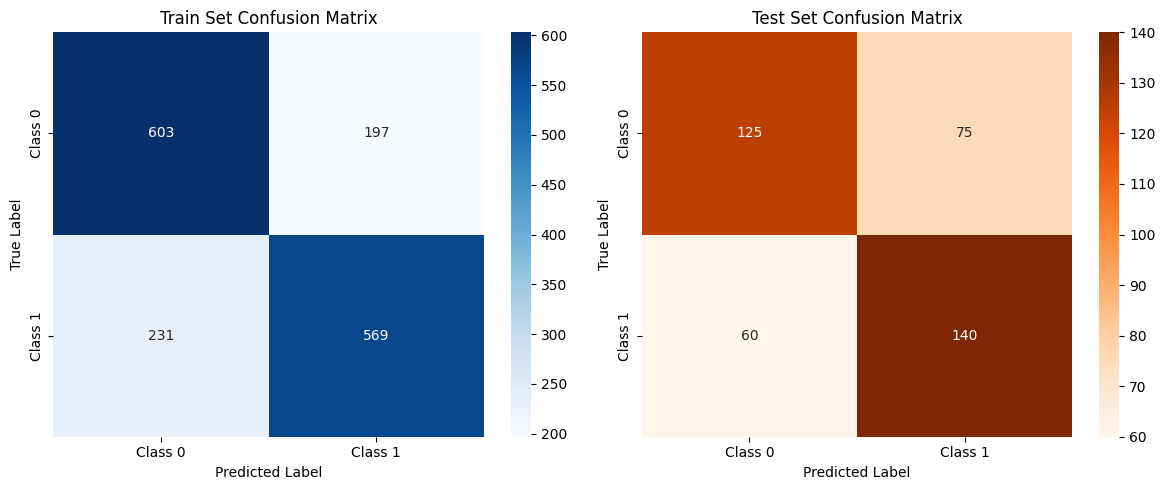

Metrics comparison saved as 'train_test_metrics_comparison.png'


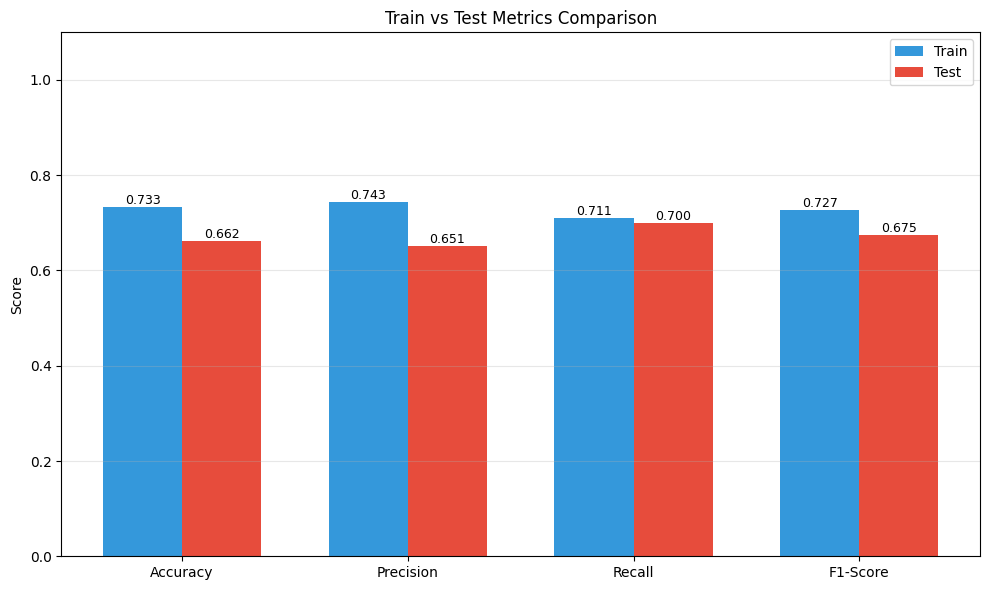


SUMMARY

Train Accuracy: 0.7325
Test Accuracy:  0.6625

Train F1-Score: 0.7267
Test F1-Score:  0.6747

⚠ Note: Significant difference between train and test accuracy.
   This might indicate overfitting.

✓ ALL PREDICTIONS COMPLETE!


In [7]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Custom Dataset Class
class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=512):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }


def predict_with_model(model_path, X_data, tokenizer, max_length=512, 
                       batch_size=16, device=None):
    """
    Make predictions using a saved BERT model.
    
    Args:
        model_path: Path to the saved model (.pt file)
        X_data: Array or list of text samples
        tokenizer: BERT tokenizer
        max_length: Maximum sequence length
        batch_size: Batch size for prediction
        device: Device to use for inference
    
    Returns:
        predictions: Array of predicted labels (0 or 1)
        probabilities: Array of probabilities for each class
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load model
    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased',
        num_labels=2
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    
    # Create dataset and dataloader
    dataset = TextDataset(X_data, tokenizer, max_length)
    dataloader = DataLoader(dataset, batch_size=batch_size)
    
    all_predictions = []
    all_probabilities = []
    
    print(f"Making predictions on {len(X_data)} samples...")
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Predicting"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)
            _, preds = torch.max(logits, dim=1)
            
            all_predictions.extend(preds.cpu().numpy())
            all_probabilities.extend(probs.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_probabilities)


def evaluate_predictions(y_true, y_pred, y_probs, set_name="Test"):
    """
    Evaluate and display metrics for predictions.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        y_probs: Prediction probabilities
        set_name: Name of the dataset (for display)
    """
    print("\n" + "="*60)
    print(f"{set_name.upper()} SET EVALUATION METRICS")
    print("="*60)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary'
    )
    
    # Macro-averaged metrics
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro'
    )
    
    # AUC-ROC
    try:
        auc_roc = roc_auc_score(y_true, y_probs[:, 1])
    except:
        auc_roc = None
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Display metrics
    print(f"\nAccuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nMacro-averaged:")
    print(f"Precision: {precision_macro:.4f}")
    print(f"Recall:    {recall_macro:.4f}")
    print(f"F1-Score:  {f1_macro:.4f}")
    if auc_roc:
        print(f"\nAUC-ROC:   {auc_roc:.4f}")
    
    print("\n" + "-"*60)
    print("Classification Report:")
    print("-"*60)
    print(classification_report(y_true, y_pred, 
                                target_names=['Class 0', 'Class 1']))
    
    print("Confusion Matrix:")
    print(cm)
    print("="*60)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': auc_roc,
        'confusion_matrix': cm
    }


def plot_confusion_matrices(train_metrics, test_metrics):
    """
    Plot confusion matrices for train and test sets side by side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Train confusion matrix
    sns.heatmap(train_metrics['confusion_matrix'], annot=True, fmt='d', 
                cmap='Blues', ax=axes[0],
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'])
    axes[0].set_title('Train Set Confusion Matrix')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # Test confusion matrix
    sns.heatmap(test_metrics['confusion_matrix'], annot=True, fmt='d', 
                cmap='Oranges', ax=axes[1],
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'])
    axes[1].set_title('Test Set Confusion Matrix')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig('train_test_confusion_matrices.png', dpi=300, bbox_inches='tight')
    print("\nConfusion matrices saved as 'train_test_confusion_matrices.png'")
    plt.show()


def plot_metrics_comparison(train_metrics, test_metrics):
    """
    Plot comparison of metrics between train and test sets.
    """
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    train_values = [
        train_metrics['accuracy'],
        train_metrics['precision'],
        train_metrics['recall'],
        train_metrics['f1']
    ]
    test_values = [
        test_metrics['accuracy'],
        test_metrics['precision'],
        test_metrics['recall'],
        test_metrics['f1']
    ]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, train_values, width, label='Train', color='#3498db')
    bars2 = ax.bar(x + width/2, test_values, width, label='Test', color='#e74c3c')
    
    ax.set_ylabel('Score')
    ax.set_title('Train vs Test Metrics Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names)
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('train_test_metrics_comparison.png', dpi=300, bbox_inches='tight')
    print("Metrics comparison saved as 'train_test_metrics_comparison.png'")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    
    print("="*60)
    print("BERT MODEL PREDICTION ON TRAIN/TEST SPLIT")
    print("="*60)
    
    # ------------------------------------------------------------------------
    # 1. LOAD YOUR DATA
    # ------------------------------------------------------------------------
    # Replace this with your actual dataframe
    # df_balanced = pd.read_csv('your_data.csv')
    
    print(f"\nDataset loaded: {len(df_balanced)} samples")
    print(f"Class distribution: {df_balanced['label'].value_counts().to_dict()}")
    
    # ------------------------------------------------------------------------
    # 2. PREPARE DATA (YOUR SPLIT)
    # ------------------------------------------------------------------------
    X = df_balanced['all_text'].values  # Use 'text' or 'github_summary' if needed
    y = df_balanced['label'].values
    
    # Check if stratification is possible
    unique, counts = np.unique(y, return_counts=True)
    class_counts = dict(zip(unique, counts))
    print(f"Class counts: {class_counts}")
    
    # Use stratify only if each class has at least 2 samples
    min_class_count = min(counts)
    use_stratify = min_class_count >= 2
    
    if use_stratify:
        print("Using stratified split...")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
    else:
        print("Warning: Cannot stratify - some classes have too few samples.")
        print("Using regular random split...")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
    
    print(f"\nTrain samples: {len(X_train)}")
    print(f"Test samples:  {len(X_test)}")
    print(f"Train class distribution: {np.bincount(y_train)}")
    print(f"Test class distribution:  {np.bincount(y_test)}")
    
    # ------------------------------------------------------------------------
    # 3. LOAD TOKENIZER AND MODEL
    # ------------------------------------------------------------------------
    print("\nLoading tokenizer and model...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model_path = 'best_model.pt'
    
    # ------------------------------------------------------------------------
    # 4. MAKE PREDICTIONS ON TRAIN SET
    # ------------------------------------------------------------------------
    print("\n" + "-"*60)
    print("PREDICTING ON TRAIN SET")
    print("-"*60)
    
    y_train_pred, y_train_probs = predict_with_model(
        model_path=model_path,
        X_data=X_train,
        tokenizer=tokenizer,
        max_length=512,
        batch_size=16,
        device=device
    )
    
    train_metrics = evaluate_predictions(y_train, y_train_pred, y_train_probs, "Train")
    
    # ------------------------------------------------------------------------
    # 5. MAKE PREDICTIONS ON TEST SET
    # ------------------------------------------------------------------------
    print("\n" + "-"*60)
    print("PREDICTING ON TEST SET")
    print("-"*60)
    
    y_test_pred, y_test_probs = predict_with_model(
        model_path=model_path,
        X_data=X_test,
        tokenizer=tokenizer,
        max_length=512,
        batch_size=16,
        device=device
    )
    
    test_metrics = evaluate_predictions(y_test, y_test_pred, y_test_probs, "Test")
    
    # ------------------------------------------------------------------------
    # 6. CREATE RESULTS DATAFRAMES
    # ------------------------------------------------------------------------
    print("\n" + "-"*60)
    print("CREATING RESULTS DATAFRAMES")
    print("-"*60)
    
    # Train results
    train_results = pd.DataFrame({
        'text': X_train,
        'true_label': y_train,
        'predicted_label': y_train_pred,
        'prob_class_0': y_train_probs[:, 0],
        'prob_class_1': y_train_probs[:, 1],
        'confidence': np.max(y_train_probs, axis=1),
        'correct': y_train == y_train_pred
    })
    
    # Test results
    test_results = pd.DataFrame({
        'text': X_test,
        'true_label': y_test,
        'predicted_label': y_test_pred,
        'prob_class_0': y_test_probs[:, 0],
        'prob_class_1': y_test_probs[:, 1],
        'confidence': np.max(y_test_probs, axis=1),
        'correct': y_test == y_test_pred
    })
    
    # Save to CSV
    train_results.to_csv('train_predictions.csv', index=False)
    test_results.to_csv('test_predictions.csv', index=False)
    
    print("\n✓ Train predictions saved to: 'train_predictions.csv'")
    print("✓ Test predictions saved to:  'test_predictions.csv'")
    
    # ------------------------------------------------------------------------
    # 7. DISPLAY SAMPLE PREDICTIONS
    # ------------------------------------------------------------------------
    print("\n" + "-"*60)
    print("SAMPLE PREDICTIONS (Test Set)")
    print("-"*60)
    print(test_results[['true_label', 'predicted_label', 'prob_class_0', 
                        'prob_class_1', 'confidence', 'correct']].head(10))
    
    # ------------------------------------------------------------------------
    # 8. PLOT RESULTS
    # ------------------------------------------------------------------------
    print("\n" + "-"*60)
    print("GENERATING VISUALIZATIONS")
    print("-"*60)
    
    plot_confusion_matrices(train_metrics, test_metrics)
    plot_metrics_comparison(train_metrics, test_metrics)
    
    # ------------------------------------------------------------------------
    # 9. SUMMARY
    # ------------------------------------------------------------------------
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"\nTrain Accuracy: {train_metrics['accuracy']:.4f}")
    print(f"Test Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"\nTrain F1-Score: {train_metrics['f1']:.4f}")
    print(f"Test F1-Score:  {test_metrics['f1']:.4f}")
    
    if train_metrics['accuracy'] - test_metrics['accuracy'] > 0.05:
        print("\n⚠ Note: Significant difference between train and test accuracy.")
        print("   This might indicate overfitting.")
    else:
        print("\n✓ Model performance is consistent between train and test sets.")
    
    print("\n" + "="*60)
    print("✓ ALL PREDICTIONS COMPLETE!")
    print("="*60)